In [1]:
import json
import os

def merge_rt_tokenizer_data():
    """
    Merge multiple RT tokenizer JSON files into a single JSON file 
    with the same structure as the normal tokenizer data.
    """
    
    # HARDCODED INPUT AND OUTPUT PATHS - MODIFY THESE AS NEEDED
    root_path = "/Users/n0w0f/structllm/RESULTS/SCALING_rt_tokenizer/"
    input_files = {
        '30k': f'{root_path}results_30k_rt_tokenizer_final.json',
        '100k': f'{root_path}results_100k_rt_tokenizer_final.json',
        '300k': f'{root_path}results_300k_rt_tokenizer_final.json',
        '2m': f'{root_path}results_2m_rt_tokenizer_final.json'
    }
    
    output_file = f'/Users/n0w0f/git/n0w0f/mattext_nips24/structllm_analysis/PAPER_JOURNAL_01/data_scaling_rt.json'
    
    merged_data = {}
    
    print("Merging RT tokenizer data files...")
    
    for data_size, file_path in input_files.items():
        print(f"Processing {data_size} data from: {file_path}")
        
        if not os.path.exists(file_path):
            print(f"Warning: File not found: {file_path}")
            continue
            
        try:
            with open(file_path, 'r') as f:
                data = json.load(f)
            
            # Add this data size to the merged data
            merged_data[data_size] = data
            
            # Print some info about the loaded data
            if data:
                representations = list(data.keys())
                properties = list(data[representations[0]].keys()) if representations else []
                print(f"  - Found {len(representations)} representations")
                print(f"  - Found {len(properties)} properties")
                print(f"  - Representations: {representations}")
                print(f"  - Properties: {properties}")
            
        except Exception as e:
            print(f"Error loading {file_path}: {e}")
            continue
    
    # Save the merged data
    if merged_data:
        with open(output_file, 'w') as f:
            json.dump(merged_data, f, indent=2)
        
        print(f"\nMerged data saved to: {output_file}")
        print(f"Data sizes included: {list(merged_data.keys())}")
        
        # Print structure summary
        if merged_data:
            first_size = list(merged_data.keys())[0]
            sample_data = merged_data[first_size]
            if sample_data:
                first_rep = list(sample_data.keys())[0]
                first_prop = list(sample_data[first_rep].keys())[0]
                print(f"\nSample data structure:")
                print(f"merged_data['{first_size}']['{first_rep}']['{first_prop}']:")
                print(json.dumps(sample_data[first_rep][first_prop], indent=2))
    else:
        print("No data was successfully loaded and merged.")

if __name__ == "__main__":
    merge_rt_tokenizer_data()

Merging RT tokenizer data files...
Processing 30k data from: /Users/n0w0f/structllm/RESULTS/SCALING_rt_tokenizer/results_30k_rt_tokenizer_final.json
  - Found 7 representations
  - Found 3 properties
  - Representations: ['cif_p1_', 'cif_symmetrized_', 'slice_', 'crystal_llm_rep_', 'composition_', 'atoms_params_', 'zmatrix_']
  - Properties: ['matbench_log_gvrh', 'matbench_log_kvrh', 'matbench_perovskites']
Processing 100k data from: /Users/n0w0f/structllm/RESULTS/SCALING_rt_tokenizer/results_100k_rt_tokenizer_final.json
  - Found 7 representations
  - Found 3 properties
  - Representations: ['cif_p1_', 'cif_symmetrized_', 'slice_', 'crystal_llm_rep_', 'composition_', 'atoms_params_', 'zmatrix_']
  - Properties: ['matbench_log_gvrh', 'matbench_log_kvrh', 'matbench_perovskites']
Processing 300k data from: /Users/n0w0f/structllm/RESULTS/SCALING_rt_tokenizer/results_300k_rt_tokenizer_final.json
  - Found 7 representations
  - Found 3 properties
  - Representations: ['cif_p1_', 'cif_symmet


Bad key font.dir in file lamalab.mplstyle, line 56 ('font.dir: /home/so87pot/n0w0f/attention_analysis/fonts')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.9.2/lib/matplotlib/mpl-data/matplotlibrc
or from the matplotlib source distribution


Loading RT tokenizer data...
Loading normal tokenizer data...
Common representations found: ['slices', 'cif_symmetrized', 'composition', 'atom_sequences_plusplus', 'crystal_text_llm', 'cif_p1', 'zmatrix']
Representations will be ordered as: ['atom_sequences_plusplus', 'composition', 'slices', 'cif_p1', 'cif_symmetrized', 'crystal_text_llm', 'zmatrix']

Calculating percentage improvements...
30k-matbench_log_gvrh-atom_sequences_plusplus: RT=0.1148, Normal=0.1215, Improvement=5.5%
30k-matbench_log_gvrh-composition: RT=0.1306, Normal=0.1355, Improvement=3.7%
30k-matbench_log_gvrh-slices: RT=0.1075, Normal=0.1059, Improvement=-1.6%
30k-matbench_log_gvrh-cif_p1: RT=0.1165, Normal=0.1132, Improvement=-2.9%
30k-matbench_log_gvrh-cif_symmetrized: RT=0.1219, Normal=0.1163, Improvement=-4.8%
30k-matbench_log_gvrh-crystal_text_llm: RT=0.1101, Normal=0.1077, Improvement=-2.2%
30k-matbench_log_gvrh-zmatrix: RT=0.1210, Normal=0.1163, Improvement=-4.0%
30k-matbench_log_kvrh-atom_sequences_plusplus: R

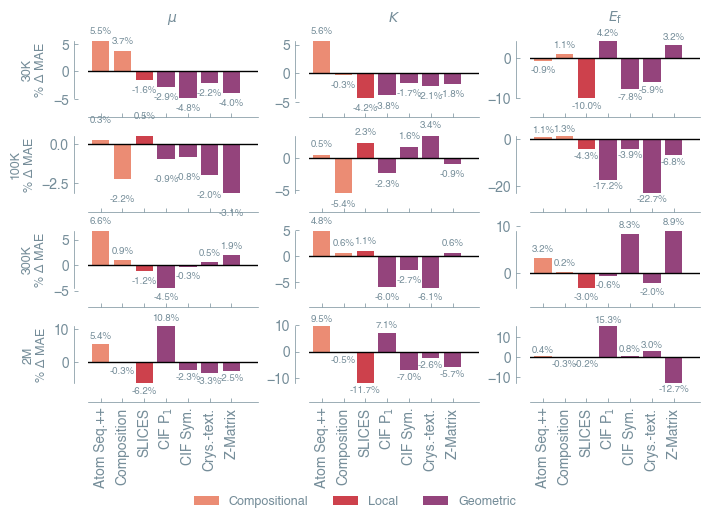

In [20]:
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import golden

# Use the provided mplstyle if available
try:
    plt.style.use("lamalab.mplstyle")
except OSError:
    print("Warning: lamalab.mplstyle not found. Using default Matplotlib style.")

# --- Constants ---
TWO_COL_WIDTH_INCH = 7.2
GOLDEN_RATIO = golden

# --- Mappings and Styles ---
REPRESENTATION_MAPPING = {
    'slice_': 'SLICES',
    'crystal_llm_rep_': 'Crys.-text.',
    'composition_': 'Composition',
    'cif_p1_': 'CIF P$_1$',
    'cif_symmetrized_': 'CIF Sym.',
    'atoms_': 'Atom Seq.',
    'atoms_params_': 'Atom Seq.++',
    'zmatrix_': 'Z-Matrix',
    'local_env_': 'Local-Env',
    # Alternative mappings for different naming conventions
    'slices': 'SLICES',
    'crystal_text_llm': 'Crys.-text.',
    'composition': 'Composition',
    'cif_p1': 'CIF P$_1$',
    'cif_symmetrized': 'CIF Sym.',
    'atom_sequences': 'Atom Seq.',
    'atom_sequences_plusplus': 'Atom Seq.++',
    'zmatrix': 'Z-Matrix',
    'local_env': 'Local-Env'
}

PROPERTY_DISPLAY_MAPPING = {
    'matbench_log_gvrh': r'$\mu$',
    'matbench_log_kvrh': r'$K$',
    'matbench_perovskites': r'$E_{\mathrm{f}}$'
}

DATA_SIZE_MAPPING = {
    '30k': '30K',
    '100k': '100K', 
    '300k': '300K',
    '2m': '2M'
}

GROUP_STYLES = {
    'compositional': {
        'color': '#e76f51',
        'members': ['composition', 'atom_sequences_plusplus', 'atom_sequences', 'composition_', 'atoms_params_', 'atoms_']
    },
    'local': {
        'color': '#c1121f',
        'members': ['local_env', 'slices', 'local_env_', 'slice_']
    },
    'geometric': {
        'color': '#79155B',
        'members': ['crystal_text_llm', 'cif_symmetrized', 'cif_p1', 'zmatrix', 'crystal_llm_rep_', 'cif_symmetrized_', 'cif_p1_', 'zmatrix_']
    }
}

def get_representation_group_and_color(representation):
    """Get the group and color for a given representation."""
    for group_name, group_info in GROUP_STYLES.items():
        if representation in group_info['members']:
            return group_name, group_info['color']
    return 'unknown', '#808080'  # Default gray for unknown representations

def range_frame(ax, x, y, pad=0.1):
    """Apply range frame styling similar to the provided script."""
    y_min, y_max = np.array(y).min(), np.array(y).max()
    x_min, x_max = np.array(x).min(), np.array(x).max()
    ax.set_ylim(y_min - pad * (y_max - y_min), y_max + pad * (y_max - y_min))
    ax.set_xlim(x_min - pad * (x_max - x_min), x_max + 2*pad * (x_max - x_min))
    ax.spines["left"].set_position(("outward", 10))
    ax.spines["bottom"].set_position(("outward", 10))
    ax.spines["left"].set_bounds(y_min, y_max)

def load_data(file_path):
    """Load JSON data from file."""
    try:
        with open(file_path, 'r') as f:
            return json.load(f)
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None

def calculate_percentage_improvement(rt_data, normal_data, data_sizes, representations, properties):
    """
    Calculate percentage improvement: ((Normal_RMSE - RT_RMSE) / Normal_RMSE) * 100
    Positive values indicate improvement (RT is better).
    """
    results = {}
    
    for size in data_sizes:
        results[size] = {}
        for prop in properties:
            results[size][prop] = {}
            
            for rep in representations:
                try:
                    # Get RT tokenizer RMSE
                    if size in rt_data and rep in rt_data[size] and prop in rt_data[size][rep]:
                        rt_rmse = rt_data[size][rep][prop]['mae']['mean']
                    else:
                        results[size][prop][rep] = None
                        continue
                    
                    # Get Normal tokenizer mae
                    if size in normal_data and rep in normal_data[size] and prop in normal_data[size][rep]:
                        normal_rmse = normal_data[size][rep][prop]['mae']['mean']
                    else:
                        results[size][prop][rep] = None
                        continue
                    
                    # Calculate percentage improvement (positive = RT better)
                    if normal_rmse != 0:
                        pct_improvement = ((normal_rmse - rt_rmse) / normal_rmse) * 100
                        results[size][prop][rep] = pct_improvement
                        print(f"{size}-{prop}-{rep}: RT={rt_rmse:.4f}, Normal={normal_rmse:.4f}, Improvement={pct_improvement:.1f}%")
                    else:
                        results[size][prop][rep] = None
                        
                except Exception as e:
                    print(f"Error calculating for {size}-{prop}-{rep}: {e}")
                    results[size][prop][rep] = None
    
    return results

def create_percentage_improvement_plot():
    """Create comparison plot showing percentage improvements using group-based coloring."""
    
    # ========== MODIFY THESE PATHS ==========
    rt_data_path = "/Users/n0w0f/git/n0w0f/mattext_nips24/structllm_analysis/PAPER_JOURNAL_01/data_scaling_rt.json"
    normal_data_path = "/Users/n0w0f/git/n0w0f/mattext_nips24/structllm_analysis/PAPER_JOURNAL_01/data_size_scaling_results.json"
    output_path = "rt_vs_normal_percentage_improvement.png"
    # ========================================
    
    # Load data
    print("Loading RT tokenizer data...")
    rt_data = load_data(rt_data_path)
    if rt_data is None:
        print("Failed to load RT tokenizer data!")
        return
        
    print("Loading normal tokenizer data...")
    normal_data = load_data(normal_data_path)
    if normal_data is None:
        print("Failed to load normal tokenizer data!")
        return
    
    # Define what to compare
    data_sizes = ['30k', '100k', '300k', '2m']
    properties = ['matbench_log_gvrh', 'matbench_log_kvrh', 'matbench_perovskites']
    
    # Get common representations from both datasets
    rt_reps = set()
    normal_reps = set()
    
    for size in data_sizes:
        if size in rt_data:
            rt_reps.update(rt_data[size].keys())
        if size in normal_data:
            normal_reps.update(normal_data[size].keys())
    
    # Find common representations
    common_reps = list(rt_reps.intersection(normal_reps))
    if not common_reps:
        print("No common representations found between datasets!")
        print(f"RT reps: {list(rt_reps)}")
        print(f"Normal reps: {list(normal_reps)}")
        return
    
    print(f"Common representations found: {common_reps}")
    
    # Sort representations by group for better visual organization
    def get_group_order(rep):
        group, _ = get_representation_group_and_color(rep)
        group_order = {'compositional': 0, 'local': 1, 'geometric': 2, 'unknown': 3}
        return group_order.get(group, 3)
    
    # Sort by group first, then alphabetically within group for consistency
    common_reps.sort(key=lambda x: (get_group_order(x), x))
    print(f"Representations will be ordered as: {common_reps}")
    
    # Calculate percentage improvements
    print("\nCalculating percentage improvements...")
    pct_improvements = calculate_percentage_improvement(rt_data, normal_data, data_sizes, common_reps, properties)
    
    # Create the plot: 4 rows (data sizes) × 3 columns (properties)
    num_rows = len(data_sizes)
    num_cols = len(properties)
    
    # Calculate figure size
    subplot_width = TWO_COL_WIDTH_INCH / num_cols
    subplot_height = subplot_width / GOLDEN_RATIO
    TWO_COL_GOLDEN_RATIO_HEIGHT_INCH = TWO_COL_WIDTH_INCH / golden
    
    fig, axes = plt.subplots(num_rows, num_cols, 
                            figsize=(TWO_COL_WIDTH_INCH, TWO_COL_GOLDEN_RATIO_HEIGHT_INCH), #num_rows * subplot_height
                            sharex=True, sharey=False)
    
    # Ensure axes is 2D
    if num_rows == 1:
        axes = axes.reshape(1, -1)
    if num_cols == 1:
        axes = axes.reshape(-1, 1)
    
    for i, size in enumerate(data_sizes):
        for j, prop in enumerate(properties):
            ax = axes[i, j]
            
            # Collect data for this subplot
            rep_names = []
            pct_values = []
            bar_colors = []
            
            for rep in common_reps:
                pct_improvement = pct_improvements[size][prop].get(rep)
                if pct_improvement is not None:
                    rep_names.append(REPRESENTATION_MAPPING.get(rep, rep))
                    pct_values.append(pct_improvement)
                    
                    # Get color based on group (regardless of positive/negative)
                    _, color = get_representation_group_and_color(rep)
                    bar_colors.append(color)
            
            if not pct_values:
                ax.text(0.5, 0.5, 'No Data', ha='center', va='center', transform=ax.transAxes)
                title = f'{DATA_SIZE_MAPPING[size]} - {PROPERTY_DISPLAY_MAPPING[prop]}'
                ax.set_title(title, fontsize=10, pad=10)
                continue
            
            # Create bar plot
            x_pos = np.arange(len(rep_names))
            bars = ax.bar(x_pos, pct_values, color=bar_colors, alpha=0.8)
            
            # Add horizontal line at y=0
            ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
            
            # Customize subplot
            if i == 0:
                title = f'{PROPERTY_DISPLAY_MAPPING[prop]}'
                ax.set_title(title, fontsize=10, pad=10)
            
            # Set y-label only for leftmost column
            if j == 0:
                ax.set_ylabel(f"{DATA_SIZE_MAPPING[size]}\n% Δ MAE", fontsize=9)
            
            # Set x-axis
            ax.set_xticks(x_pos)
            ax.set_xticklabels(rep_names, fontsize=8)
            
            # Force rotation using setp for better control
            #plt.setp(ax.get_xticklabels(), rotation=90, ha='center')
            
            # Apply rangeframe styling
            range_frame(ax, x_pos, pct_values)
            
            # Turn off grid (matching the provided script style)
            ax.grid(False)
            ax.set_axisbelow(True)
            
            # Add value labels on bars
            for bar, val in zip(bars, pct_values):
                height = bar.get_height()
                label_y = height + (1 if height >= 0 else -1)
                ax.text(bar.get_x() + bar.get_width()/2., label_y,
                       f'{val:.1f}%', ha='center', va='bottom' if height >= 0 else 'top', 
                       fontsize=7, fontweight='bold')
    
    # Create custom legend based on groups
    legend_elements = []
    for group_name, group_info in GROUP_STYLES.items():
        legend_elements.append(plt.Rectangle((0,0),1,1, 
                                           facecolor=group_info['color'], 
                                           alpha=0.8,
                                           label=group_name.capitalize()))
    
    # Add legend
    fig.legend(handles=legend_elements, 
              loc='upper center', 
              bbox_to_anchor=(0.5, -0.1),
              ncol=len(legend_elements), 
              frameon=False, 
              fontsize=9)
    
    # Adjust layout
    plt.tight_layout()
    plt.subplots_adjust(wspace=0.3, hspace=0.4)


    # Force rotation after layout adjustments
    for i in range(num_rows):
        for j in range(num_cols):
            ax = axes[i, j]
            for tick in ax.get_xticklabels():
                tick.set_rotation(90)
                tick.set_horizontalalignment('center')

    
    
    # Save plot
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.savefig(output_path.replace('.png', '.pdf'), dpi=300, bbox_inches='tight')
    
    print(f"\nComparison plot saved to: {output_path}")
    
    # Print summary statistics
    print("\n" + "="*50)
    print("SUMMARY STATISTICS")
    print("="*50)
    
    all_improvements = []
    all_degradations = []
    total_comparisons = 0
    
    for size in data_sizes:
        for prop in properties:
            for rep in common_reps:
                pct_improvement = pct_improvements[size][prop].get(rep)
                if pct_improvement is not None:
                    total_comparisons += 1
                    if pct_improvement > 0:
                        all_improvements.append(pct_improvement)
                    else:
                        all_degradations.append(abs(pct_improvement))
    
    improvement_count = len(all_improvements)
    degradation_count = len(all_degradations)
    
    print(f"Total comparisons: {total_comparisons}")
    print(f"RT improvements: {improvement_count} ({100*improvement_count/total_comparisons:.1f}%)")
    print(f"RT degradations: {degradation_count} ({100*degradation_count/total_comparisons:.1f}%)")
    
    if all_improvements:
        print(f"\nImprovement stats (positive values):")
        print(f"  Average improvement: {np.mean(all_improvements):.1f}%")
        print(f"  Max improvement: {np.max(all_improvements):.1f}%")
        print(f"  Min improvement: {np.min(all_improvements):.1f}%")
    
    if all_degradations:
        print(f"\nDegradation stats (negative values):")
        print(f"  Average degradation: {np.mean(all_degradations):.1f}%")
        print(f"  Max degradation: {np.max(all_degradations):.1f}%")
        print(f"  Min degradation: {np.min(all_degradations):.1f}%")
    
    plt.show()

if __name__ == "__main__":
    create_percentage_improvement_plot()